## Importing Libraries

In [182]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import math

from sklearn import datasets
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score,recall_score,confusion_matrix,classification_report,r2_score,mean_squared_error
from sklearn.neighbors import KNeighborsClassifier
from sklearn.model_selection import StratifiedKFold
kFold = StratifiedKFold(n_splits=5)


## Dataset

In [183]:
df = pd.read_csv("../00_Datasets/Iris.csv")

In [184]:
df.head()

,Id,SepalLengthCm,SepalWidthCm,PetalLengthCm,PetalWidthCm,Species
0,1,5.1,3.5,1.4,0.2,Iris-setosa
1,2,4.9,3.0,1.4,0.2,Iris-setosa
2,3,4.7,3.2,1.3,0.2,Iris-setosa
3,4,4.6,3.1,1.5,0.2,Iris-setosa
4,5,5.0,3.6,1.4,0.2,Iris-setosa


## EDA

In [185]:
df.shape

(150, 6)

In [186]:
df.columns

Index(['Id', 'SepalLengthCm', 'SepalWidthCm', 'PetalLengthCm', 'PetalWidthCm',
       'Species'],
      dtype='object')

In [187]:
df

,Id,SepalLengthCm,SepalWidthCm,PetalLengthCm,PetalWidthCm,Species
0,1,5.1,3.5,1.4,0.2,Iris-setosa
1,2,4.9,3.0,1.4,0.2,Iris-setosa
2,3,4.7,3.2,1.3,0.2,Iris-setosa
3,4,4.6,3.1,1.5,0.2,Iris-setosa
4,5,5.0,3.6,1.4,0.2,Iris-setosa
...,...,...,...,...,...,...
145,146,6.7,3.0,5.2,2.3,Iris-virginica
146,147,6.3,2.5,5.0,1.9,Iris-virginica
147,148,6.5,3.0,5.2,2.0,Iris-virginica
148,149,6.2,3.4,5.4,2.3,Iris-virginica


In [188]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 150 entries, 0 to 149
Data columns (total 6 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Id             150 non-null    int64  
 1   SepalLengthCm  150 non-null    float64
 2   SepalWidthCm   150 non-null    float64
 3   PetalLengthCm  150 non-null    float64
 4   PetalWidthCm   150 non-null    float64
 5   Species        150 non-null    object 
dtypes: float64(4), int64(1), object(1)
memory usage: 7.2+ KB


In [189]:
df.describe()

,Id,SepalLengthCm,SepalWidthCm,PetalLengthCm,PetalWidthCm
count,150.000000,150.000000,150.000000,150.000000,150.000000
mean,75.500000,5.843333,3.054000,3.758667,1.198667
std,43.445368,0.828066,0.433594,1.764420,0.763161
min,1.000000,4.300000,2.000000,1.000000,0.100000
25%,38.250000,5.100000,2.800000,1.600000,0.300000
50%,75.500000,5.800000,3.000000,4.350000,1.300000
75%,112.750000,6.400000,3.300000,5.100000,1.800000
max,150.000000,7.900000,4.400000,6.900000,2.500000


In [190]:
df.isnull().sum()

Id               0
SepalLengthCm    0
SepalWidthCm     0
PetalLengthCm    0
PetalWidthCm     0
Species          0
dtype: int64

Species
Iris-setosa        50
Iris-versicolor    50
Iris-virginica     50
Name: count, dtype: int64


<Axes: xlabel='Species', ylabel='count'>

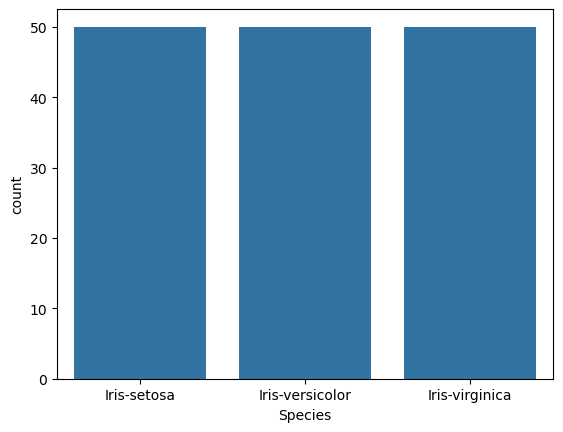

In [191]:
print(df.Species.value_counts())
sns.countplot(x='Species', data=df)

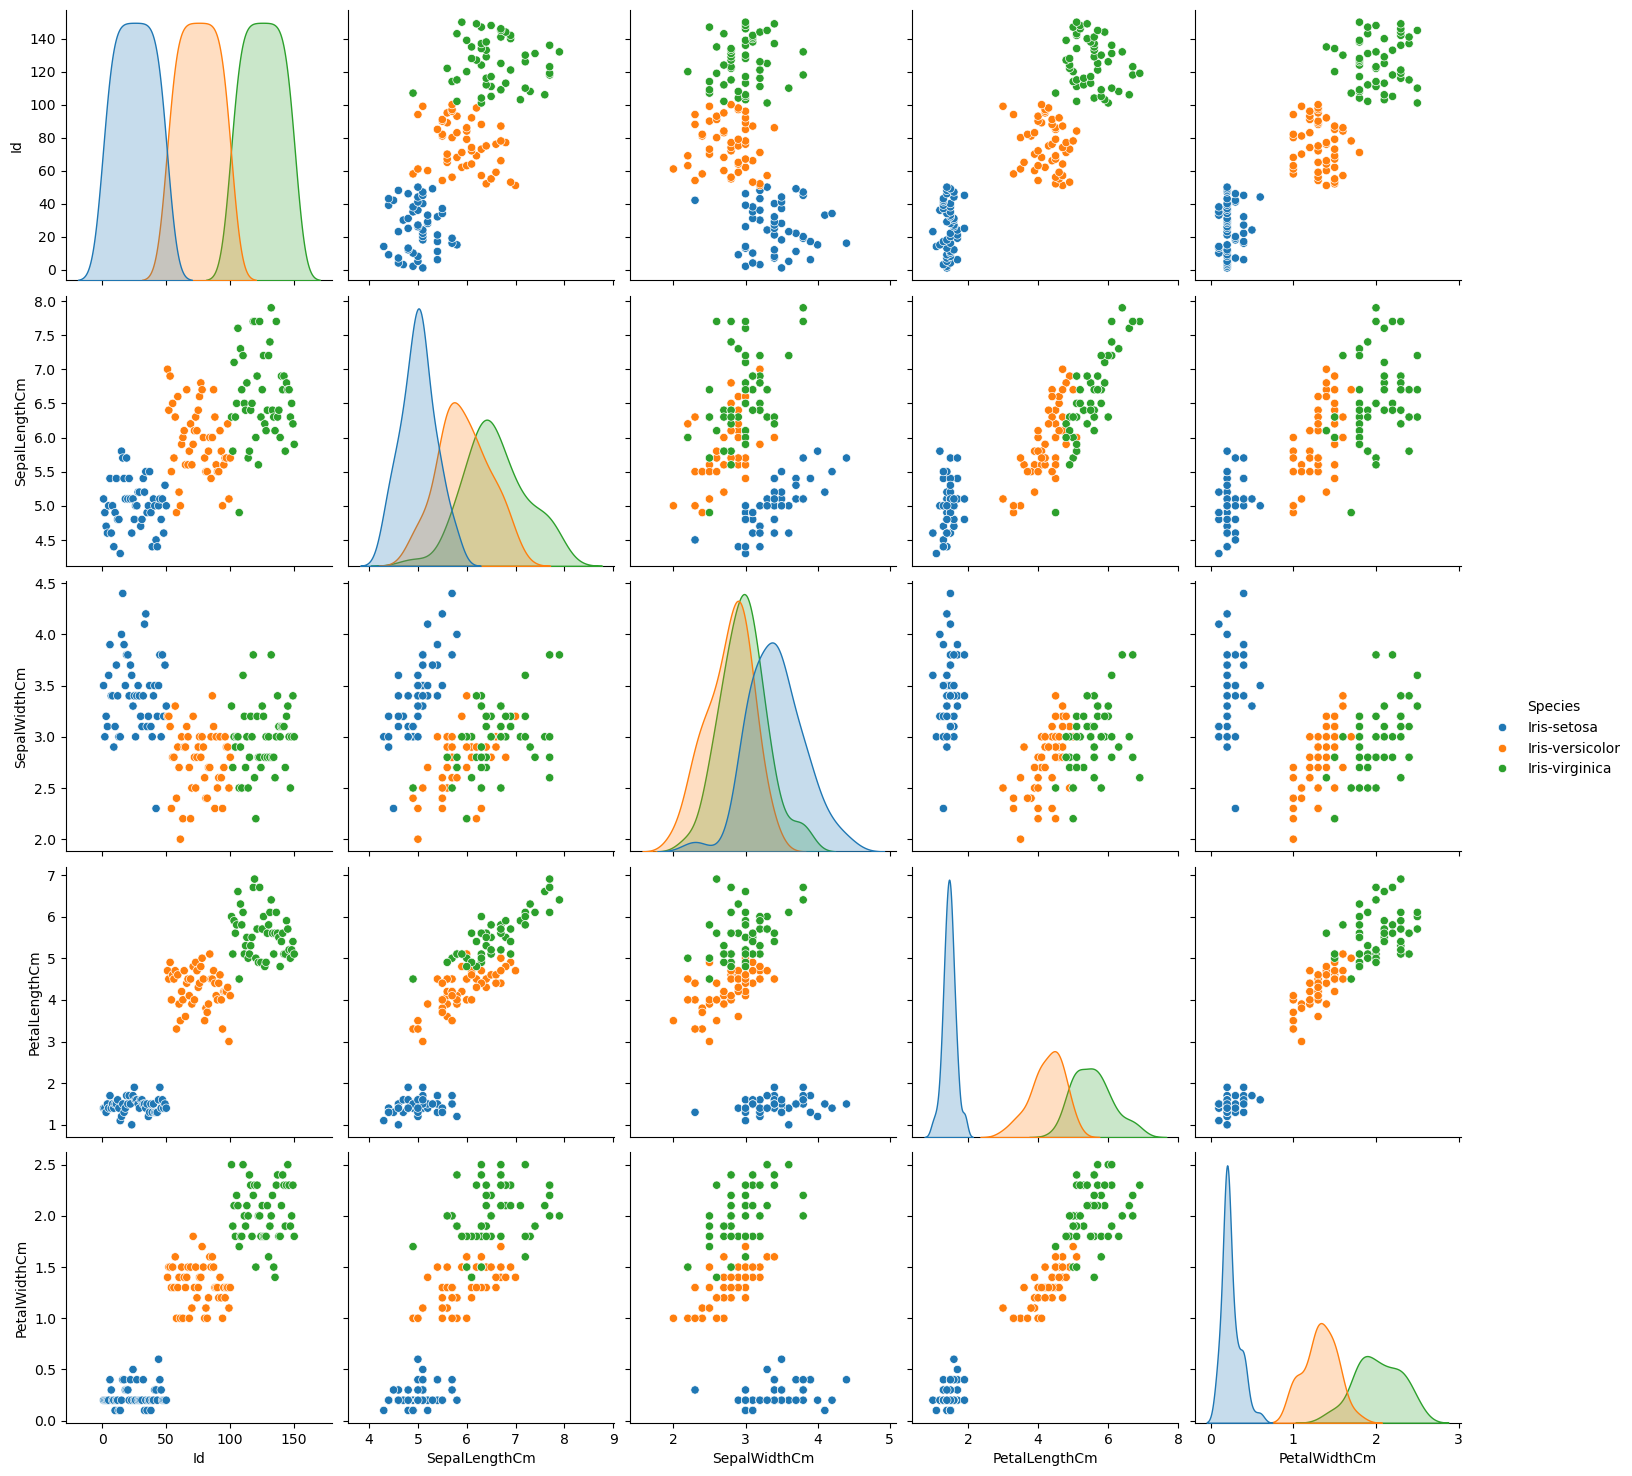

In [192]:
sns.pairplot(df,hue="Species",height=3,aspect=1)

<Axes: >

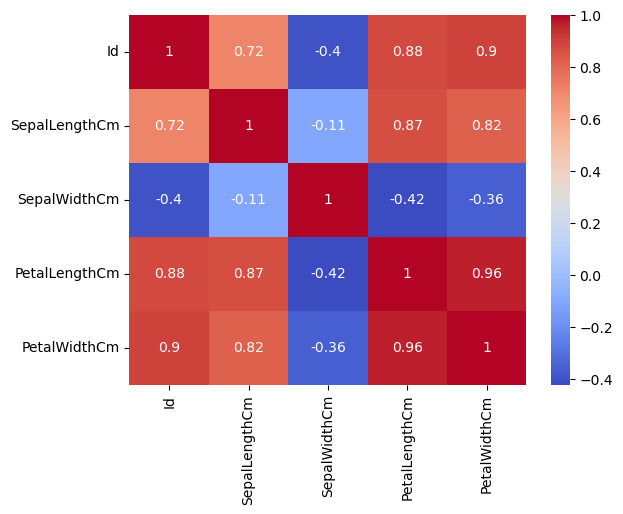

In [193]:
sns.heatmap(df.corr(numeric_only=True), annot=True, cmap="coolwarm")

## Feature Scaling

In [194]:
X = df.drop('Species', axis=1)
y = df['Species']

## Train-Test Split

In [195]:
X_train, X_test, y_train, y_test = train_test_split(
  X, y, test_size=0.2, random_state=42
)

In [196]:
# Using Standard scaler for feature scaling
scaler = StandardScaler()
scaler.fit(X_train)
X_train = scaler.transform(X_train)
X_test = scaler.transform(X_test)

In [197]:
knn = KNeighborsClassifier(n_neighbors=5)

In [198]:
knn.fit(X_train, y_train)

KNeighborsClassifier()

In [199]:
y_pred = knn.predict(X_test)

In [200]:
y_pred

array(['Iris-versicolor', 'Iris-setosa', 'Iris-virginica',
       'Iris-versicolor', 'Iris-versicolor', 'Iris-setosa',
       'Iris-versicolor', 'Iris-virginica', 'Iris-versicolor',
       'Iris-versicolor', 'Iris-virginica', 'Iris-setosa', 'Iris-setosa',
       'Iris-setosa', 'Iris-setosa', 'Iris-versicolor', 'Iris-virginica',
       'Iris-versicolor', 'Iris-versicolor', 'Iris-virginica',
       'Iris-setosa', 'Iris-virginica', 'Iris-setosa', 'Iris-virginica',
       'Iris-virginica', 'Iris-virginica', 'Iris-virginica',
       'Iris-virginica', 'Iris-setosa', 'Iris-setosa'], dtype=object)

In [201]:
accuracy_score(y_test, y_pred)

1.0

# Hyperparameter Tuning

In [202]:

knn_clf = KNeighborsClassifier()
param_grid = {'n_neighbors' : [1,2,3,4,5,7,8,9,10,11,12]}
grid_search = GridSearchCV (knn_clf, param_grid, cv=kFold,scoring = 'recall_weighted', return_train_score=True)
grid_search.fit(X_train, y_train)

GridSearchCV(cv=StratifiedKFold(n_splits=5, random_state=None, shuffle=False),
             estimator=KNeighborsClassifier(),
             param_grid={'n_neighbors': [1, 2, 3, 4, 5, 7, 8, 9, 10, 11, 12]},
             return_train_score=True, scoring='recall_weighted')

In [203]:
grid_search.best_params_

{'n_neighbors': 3}

In [204]:
knnclassifier = KNeighborsClassifier(n_neighbors=3)
knnclassifier.fit(X_train, y_train)
y_pred = knnclassifier.predict(X_test)

## Evaluation

In [205]:
knn_train_accuracy = accuracy_score(y_train, knnclassifier.predict(X_train))
knn_test_accuracy = accuracy_score(y_test, knnclassifier.predict(X_test))

In [206]:
knn_train_accuracy, knn_test_accuracy

(0.9916666666666667, 1.0)

[[10  0  0]
 [ 0  9  0]
 [ 0  0 11]]


<Axes: >

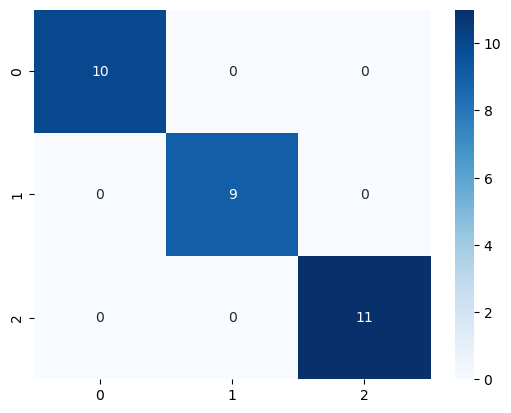

In [207]:
# Confusion Matrix
cm = confusion_matrix(y_test, y_pred)
print(cm)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')

In [208]:
print(classification_report(y_test, y_pred))

                 precision    recall  f1-score   support

    Iris-setosa       1.00      1.00      1.00        10
Iris-versicolor       1.00      1.00      1.00         9
 Iris-virginica       1.00      1.00      1.00        11

       accuracy                           1.00        30
      macro avg       1.00      1.00      1.00        30
   weighted avg       1.00      1.00      1.00        30



c:\Users\Purvi jain\anaconda3\Lib\site-packages\sklearn\utils\validation.py:2739: UserWarning: X does not have valid feature names, but KNeighborsClassifier was fitted with feature names
  warnings.warn(


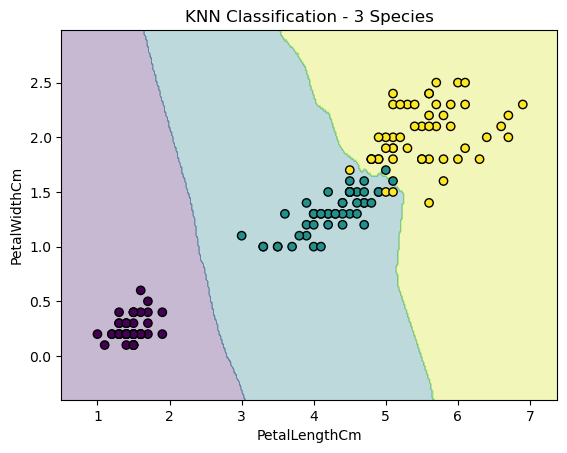

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.neighbors import KNeighborsClassifier
from sklearn.preprocessing import LabelEncoder

# Select only 2 features for visualization
X_2d = X.iloc[:, [0, 1]]

# Create a new KNN model for 2 features
knn_2d = KNeighborsClassifier(n_neighbors=5)
knn_2d.fit(X_2d, y)

# Create mesh grid
x_min = X_2d.iloc[:, 0].min() - 0.5
x_max = X_2d.iloc[:, 0].max() + 0.5

y_min = X_2d.iloc[:, 1].min() - 0.5
y_max = X_2d.iloc[:, 1].max() + 0.5

xx, yy = np.meshgrid(
    np.arange(x_min, x_max, 0.02),
    np.arange(y_min, y_max, 0.02)
)

# Predict using the NEW 2-feature model
Z = knn_2d.predict(np.c_[xx.ravel(), yy.ravel()])

# Convert species names to numbers if needed
le = LabelEncoder()
y_encoded = le.fit_transform(y)

Z_encoded = le.transform(Z)
Z_encoded = Z_encoded.reshape(xx.shape)

# Plot decision boundary
plt.contourf(xx, yy, Z_encoded, alpha=0.3, cmap="viridis")

# Plot actual data points
plt.scatter(
    X_2d.iloc[:, 0],
    X_2d.iloc[:, 1],
    c=y_encoded,
    cmap="viridis",
    edgecolor="black"
)

plt.xlabel(X_2d.columns[0])
plt.ylabel(X_2d.columns[1])
plt.title("KNN Classification - 3 Species")

plt.show()